# Agentic Rag with Langgraph

In [9]:
uv add langchain.text_splitter

Note: you may need to restart the kernel to use updated packages.


d:\Agentic-AI-Practice\.venv\Scripts\python.exe: No module named uv


In [10]:
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document



In [11]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [12]:
from openai import embeddings
import os
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:openai/gpt-oss-20b")

In [13]:
import os
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings

load_dotenv()

# Initialize OpenRouter Embedding Model
embeddings = OpenAIEmbeddings(
    model="nvidia/nemotron-3-embed-1b:free",
    openai_api_key=os.getenv("OPENROUTER_API_KEY"),
    openai_api_base="https://openrouter.ai/api/v1",
    check_embedding_ctx_length=False,  # Disables OpenAI-specific token counting
    tiktoken_enabled=False             # Disables tiktoken tokenizer for non-OpenAI models
)

# Test generating a single embedding
query_vector = embeddings.embed_query("Your text string goes here")
print(f"Embedding length: {len(query_vector)}")
print(f"Sample values: {query_vector[:5]}")


Embedding length: 2048
Sample values: [0.15173478424549103, -0.023006511852145195, -0.03310033306479454, -0.026551449671387672, -0.0043760063126683235]


# State Definition

In [14]:
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

In [17]:
!uv add langchain-chroma


Resolved 152 packages in 30ms
Checked 147 packages in 35ms


In [18]:
### Sample Document And VectorStore
from langchain_chroma import Chroma

# Sample documents for demonstration
sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.",
    "RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.",
    "Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.",
    "Agentic systems are AI systems that can take actions, make decisions, and interact with their environment autonomously. They often use planning and reasoning capabilities."
]

documents = [Document(page_content=text) for text in sample_texts]

## Create Chroma vector store (In-Memory)
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    collection_name="agentic_rag"
)

## Create retriever
# Note: In LangChain, pass 'k' via search_kwargs
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


In [20]:
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    collection_name="agentic_rag",
    persist_directory="./chroma_db"
)


In [21]:
results = retriever.invoke("What is LangGraph?")
for i, doc in enumerate(results):
    print(f"\nResult {i+1}: {doc.page_content}")



Result 1: LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.

Result 2: RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.

Result 3: Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.


# Agents function

In [22]:
def decide_retrieval(state: AgentState) -> AgentState:
    """
    Decide if we need to retrieve documents based on the question
    """
    question = state["question"]
    
    # Simple heuristic: if question contains certain keywords, retrieve
    retrieval_keywords = ["what", "how", "explain", "describe", "tell me"]
    needs_retrieval = any(keyword in question.lower() for keyword in retrieval_keywords)
    
    return {**state, "needs_retrieval": needs_retrieval}

In [23]:
def retrieve_documents(state: AgentState) -> AgentState:
    """
    Retrieve relevant documents based on the question
    """
    question = state["question"]
    documents = retriever.invoke(question)
    
    return {**state, "documents": documents}

In [24]:
def generate_answer(state: AgentState) -> AgentState:
    """
    Generate an answer using the retrieved documents or direct response
    """
    question = state["question"]
    documents = state.get("documents", [])
    
    if documents:
        # RAG approach: use documents as context
        context = "\n\n".join([doc.page_content for doc in documents])
        prompt = f"""Based on the following context, answer the question:

Context:
{context}

Question: {question}

Answer:"""
    else:
        # Direct response without retrieval
        prompt = f"Answer the following question: {question}"
    
    response = llm.invoke(prompt)
    answer = response.content
    
    return {**state, "answer": answer}

# Conditional Logic 

In [25]:
def should_retrieve(state: AgentState) -> str:
    """
    Determine the next step based on retrieval decision
    """
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

# build the Graph

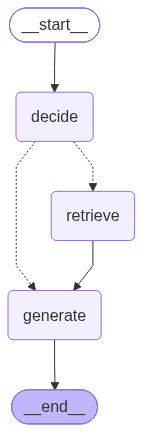

In [28]:
# Create the state graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("generate", generate_answer)

# Set entry point
workflow.set_entry_point("decide")

# Add conditional edges
workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve": "retrieve",
        "generate": "generate"
    }
)

# Add edges
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

# Compile the graph
app = workflow.compile()
app

# test the Agentic System

In [31]:
def ask_question(question: str):
    """
    Helper function to ask a question and get an answer
    """
    initial_state = {
        "question": question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False
    }
    
    result = app.invoke(initial_state)
    return result

In [32]:
# Test with a question that should trigger retrieval
question1 = "What is LangGraph?"
result1 = ask_question(question1)
result1

{'question': 'What is LangGraph?',
 'documents': [Document(id='1a5c53f0-1a85-41b9-9104-134e76d992ea', metadata={}, page_content='LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.'),
  Document(id='5cddad9c-907e-4ba3-bd34-ea19cb912c9a', metadata={}, page_content='RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.'),
  Document(id='806d2c0c-9e21-46aa-b705-3c8fe3846877', metadata={}, page_content='Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.')],
 'answer': 'LangGraph is a library that enables the construction of stateful, multi‑actor appl

In [33]:
# Test with another question
question2 = "How does RAG work?"
result2 = ask_question(question2)

print(f"Question: {question2}")
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "="*50 + "\n")

Question: How does RAG work?
Retrieved documents: 3
Answer: **RAG (Retrieval‑Augmented Generation)** is a two‑stage pipeline that blends a retrieval system with a language‑generation model so that the model can “look up” relevant information before answering a query.  
Here’s a step‑by‑step breakdown of how it works:

| Step | What Happens | Key Components | Typical Implementation |
|------|--------------|----------------|------------------------|
| **1. Encode the user query** | The raw text of the user’s question is converted into a dense vector representation. | Query encoder (often a transformer, e.g., BERT, RoBERTa, or a specialized retrieval encoder). | `query_vector = encoder(query_text)` |
| **2. Retrieve relevant documents** | The query vector is used to search a vector database (or a traditional index) for the most semantically similar passages. | Vector database (FAISS, Milvus, Pinecone, etc.), similarity metric (cosine, dot‑product). | `docs = vector_db.search(query_vector,